<a href="https://colab.research.google.com/github/sevaradevoloper/machine-learning-class-work/blob/main/logisticregression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# logistic reg => Diabet

In [1]:
!pip install opendatasets legacy-cgi

In [2]:
import opendatasets as od

In [11]:
od.download("https://www.kaggle.com/datasets/hakim11/pima-diabetes")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: sevaradev
Dataset URL: https://www.kaggle.com/datasets/hakim11/pima-diabetes


100%|██████████| 8.91k/8.91k [00:00<00:00, 13.3MB/s]

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


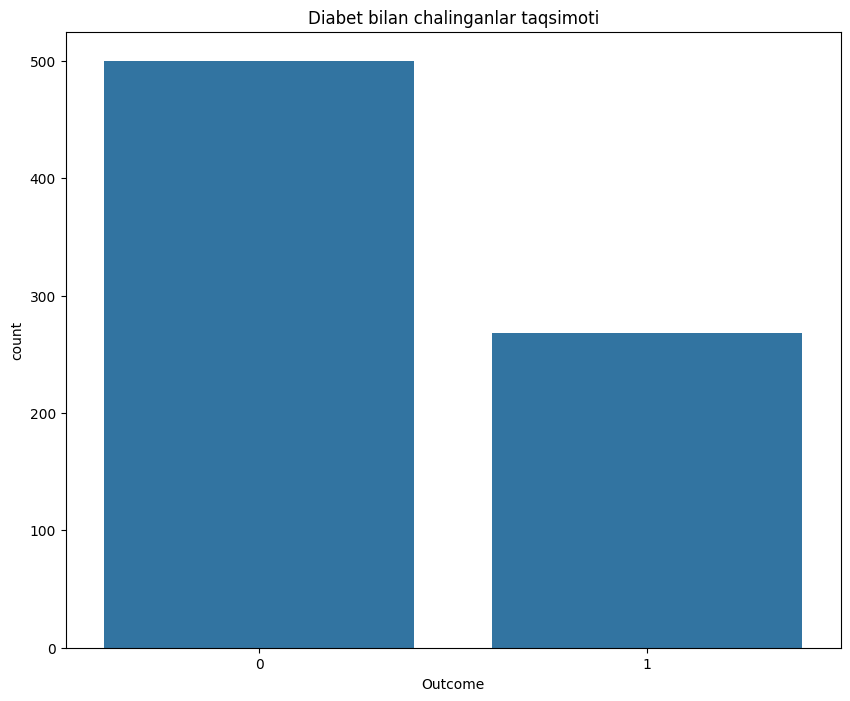

===== Logistic metrics ======
Accuracy score
0.7337662337662337
Confusion matrix: 
[[75 25]
 [16 38]]
Classifier report:
              precision    recall  f1-score   support

           0       0.82      0.75      0.79       100
           1       0.60      0.70      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154



In [37]:
df = pd.read_csv("/content/pima-diabetes/diabetes.csv")
print(df.columns.tolist())

# targetni tekshiramiz

plt.figure(figsize=(10,8))
sns.countplot(data=df,x='Outcome')
plt.title('Diabet bilan chalinganlar taqsimoti')
plt.show()

zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_columns:
    df[col] = df[col].replace(0, np.nan)

# imbalanced ekan class_weight='balanced'qoyib  ketish kere fit da
X = df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', ]]
y = df['Outcome']

X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2,stratify=y)
for col in zero_columns:
    median_val = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_val)
    X_test[col] = X_test[col].fillna(median_val)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = LogisticRegression(class_weight ='balanced')
model.fit(X_train_scaled,y_train)


# metrics

def show_metrics(y_true,y_pred):
  conf_mat = confusion_matrix(y_true,y_pred)
  report = classification_report(y_true,y_pred)
  acc_score = accuracy_score(y_true,y_pred)
  print("===== Logistic metrics ======")
  print("Accuracy score")
  print(acc_score)
  print("Confusion matrix: ")
  print(conf_mat)
  print("Classifier report:")
  print(report)

y_pred = model.predict(X_test_scaled)

show_metrics(y_test,y_pred)